<a href="https://colab.research.google.com/github/liangjizhu/ArendizajeAutomatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del Abandono de Empleados
# **Objetivo:**  
Predecir si un empleado abandonará la empresa (burnout/attrition) mediante diversas técnicas de aprendizaje automático.
# **Estructura del Notebook:**
1. Introducción y Objetivos
2. Exploración de Datos (EDA)
3. Preprocesamiento de los Datos (pipelines, escalado e imputación)
4. Modelado:  
    - Modelos básicos: KNN y Árboles  
    - Modelos avanzados: Regresión Logística y SVM  
5. Evaluación interna (inner) y selección del modelo final
6. Guardado del modelo final
7. Conclusiones y comentarios (incluyendo el uso de ChatGPT)
#
**Nota:** Se utiliza el dataset `attrition_availabledata_05.csv` ubicado en la carpeta `lab1/data/`.



In [8]:
# 1. Importación de librerías y configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# Fijamos la semilla para la reproducibilidad (NIA)
SEED = 495723
np.random.seed(SEED)

## 2. Carga y Exploración de Datos (EDA)

En esta sección se carga el dataset, se exploran sus dimensiones, tipos de variables, valores faltantes y el balance de la variable objetivo.


In [9]:
# Cargar el dataset de entrenamiento
data_path = "lab1/data/attrition_availabledata_05.csv"  # Ajusta la ruta si es necesario
df = pd.read_csv(data_path)
print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)

# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (2940, 31)

Tipos de variables:
hrs                        float64
absences                     int64
JobInvolvement               int64
PerformanceRating            int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
WorkLifeBalance            float64
Age                          int64
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int6

### Visualización del Balance de la Variable Objetivo

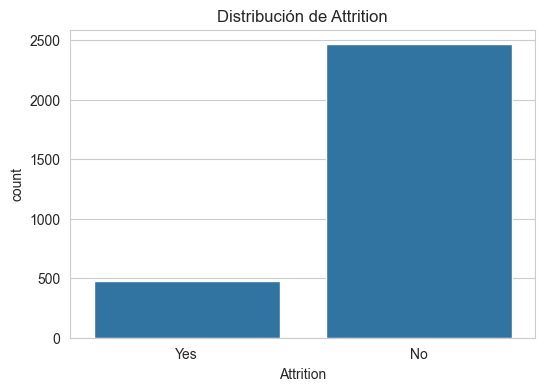

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Distribución de Attrition")
plt.show()

## 3. Preprocesamiento de los Datos
Se prepara un pipeline para el preprocesamiento que incluya imputación (estrategia mediana o media) y escalado (se usa StandardScaler, pero se pueden probar otros como RobustScaler y MinMaxScaler).


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Seleccionar columnas numéricas (excluyendo IDs o columnas que no se desean transformar)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Excluir columnas que no queremos procesar
cols_excluir = ['EmployeeID', 'EmployeeCount', 'Attrition']
num_cols = [col for col in num_cols if col not in cols_excluir]
cat_cols = [col for col in cat_cols if col not in cols_excluir]



## 4. División de Datos: Holdout (2/3 train y 1/3 test)
Se separan los datos en conjunto de entrenamiento (train) y prueba (test) para la evaluación outer.


In [12]:
# Proceed with the preprocessing and splitting
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['Attrition'])
y = df['Attrition']
label_encoder = LabelEncoder()
y= label_encoder.fit_transform(y)
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=SEED,stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1960, 30) Test: (980, 30)


## 5. Modelado
Se evalúan diferentes modelos:

### 5.1 Modelos Básicos: KNN y Árboles
Primero se entrenan con sus parámetros por defecto y se mide el tiempo de entrenamiento.


Probamos diferentes pipelines para ver si se mejora el rendimiento del modelo KNN.

In [13]:
from sklearn.model_selection import cross_val_score

# Define the parameter grid for KNN
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

# Define the different numeric pipelines
numeric_pipelines = [
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', RobustScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())]),
    Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())])
]

# Define the categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Loop through each numeric pipeline and perform GridSearchCV
for i, numeric_pipeline in enumerate(numeric_pipelines):
    print(f"Evaluating pipeline {i+1}")

    # Combine the numeric and categorical pipelines
    preprocessing_pipeline = ColumnTransformer(transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ])

    # Define the full pipeline with KNN
    knn_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessing_pipeline),
        ('knn', KNeighborsClassifier())
    ])

    cv_scores = cross_val_score(knn_pipeline,X_train, y_train, cv=3, scoring='balanced_accuracy')

    print("Cross-validation balanced accuracy scores: ", cv_scores)
    print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))


Evaluating pipeline 1
Cross-validation balanced accuracy scores:  [0.5942019  0.57921446 0.58925096]
Mean cross-validation balanced accuracy: 0.5876
Evaluating pipeline 2
Cross-validation balanced accuracy scores:  [0.59891888 0.57921446 0.58925096]
Mean cross-validation balanced accuracy: 0.5891
Evaluating pipeline 3
Cross-validation balanced accuracy scores:  [0.61671946 0.60738617 0.60829857]
Mean cross-validation balanced accuracy: 0.6108
Evaluating pipeline 4
Cross-validation balanced accuracy scores:  [0.61671946 0.60738617 0.60829857]
Mean cross-validation balanced accuracy: 0.6108
Evaluating pipeline 5
Cross-validation balanced accuracy scores:  [0.59177455 0.5790146  0.6086983 ]
Mean cross-validation balanced accuracy: 0.5932
Evaluating pipeline 6
Cross-validation balanced accuracy scores:  [0.59177455 0.5837765  0.6086983 ]
Mean cross-validation balanced accuracy: 0.5947


Seleccionar el mejor pipeline que es RobustScaler + SimpleImputer(strategy='mean')

### KNN Default

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Define the numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Define the categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the numeric and categorical pipelines
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Define the full pipeline with KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('knn', KNeighborsClassifier())
])

# Perform 3-fold cross-validation
cv_scores = cross_val_score(knn_pipeline,X_train, y_train, cv=3, scoring='balanced_accuracy')

print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))

Cross-validation balanced accuracy scores:  [0.61671946 0.60738617 0.60829857]
Mean cross-validation balanced accuracy: 0.6108


### KNN HPO

In [15]:
param_grid = {
    'knn__n_neighbors': [3],
    'knn__weights': ['distance'],
    'knn__metric': ['manhattan']
}
grid_search = GridSearchCV(estimator=knn_pipeline, param_grid=param_grid, cv=3, scoring='balanced_accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters found: ", best_params)
print("Best cross-validation balanced accuracy: {:.4f}".format(best_score))

Best parameters found:  {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best cross-validation balanced accuracy: 0.7808


### Arboles default

In [16]:
from sklearn import metrics
from sklearn import tree

# Define the full pipeline with KNN
tree = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline),
    ('tree', DecisionTreeClassifier(random_state=SEED))
])

scores = cross_val_score(tree, X_train, y_train, scoring='balanced_accuracy', cv = 3)
print("Cross-validation balanced accuracy scores: ", cv_scores)
print("Mean cross-validation balanced accuracy: {:.4f}".format(cv_scores.mean()))


Cross-validation balanced accuracy scores:  [0.61671946 0.60738617 0.60829857]
Mean cross-validation balanced accuracy: 0.6108


### Arboles HPO

In [20]:
param_grid = {
    'tree__max_depth': [5, 10, 15, 20],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4, 6]
}

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=3, scoring='balanced_accuracy')
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best parameters found: ", best_params)
print("Best cross-validation balanced accuracy: {:.4f}".format(best_score))

Best parameters found:  {'tree__max_depth': 15, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best cross-validation balanced accuracy: 0.7503


### 5.2 Modelos Avanzados: Regresión Logística y SVM